In [41]:
pip install missingno


Note: you may need to restart the kernel to use updated packages.


In [42]:
pip install covid19dh


Note: you may need to restart the kernel to use updated packages.


In [43]:
import pandas as pd
from covid19dh import covid19
import missingno as msno

In [44]:
from datetime import date
x, src = covid19("USA", level=2, start = date(2020,3,1), end = "2020-06-01")

We have invested a lot of time and effort in creating COVID-19 Data Hub, please cite the following when using it:

	Guidotti, E., Ardia, D., (2020), "COVID-19 Data Hub", Journal of Open Source Software 5(51):2376, doi: 10.21105/joss.02376.

A BibTeX entry for LaTeX users is

	@Article{,
		title = {COVID-19 Data Hub},
		year = {2020},
		doi = {10.21105/joss.02376},
		author = {Emanuele Guidotti and David Ardia},
		journal = {Journal of Open Source Software},
		volume = {5},
		number = {51},
		pages = {2376},
	}

To hide this message use 'verbose = False'.


In [45]:
x.head()

,id,date,confirmed,deaths,recovered,tests,vaccines,people_vaccinated,people_fully_vaccinated,hosp,...,iso_alpha_3,iso_alpha_2,iso_numeric,iso_currency,key_local,key_google_mobility,key_apple_mobility,key_jhu_csse,key_nuts,key_gadm
40357,10b692cc,2020-03-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,USA,US,840.0,USD,69,NaN,Northern Mariana Islands,US69,NaN,MNP
40358,10b692cc,2020-03-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,USA,US,840.0,USD,69,NaN,Northern Mariana Islands,US69,NaN,MNP
40359,10b692cc,2020-03-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,USA,US,840.0,USD,69,NaN,Northern Mariana Islands,US69,NaN,MNP
40360,10b692cc,2020-03-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,USA,US,840.0,USD,69,NaN,Northern Mariana Islands,US69,NaN,MNP
40361,10b692cc,2020-03-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,USA,US,840.0,USD,69,NaN,Northern Mariana Islands,US69,NaN,MNP


In [46]:
x.dtypes



id                                             object
date                                   datetime64[ns]
confirmed                                     float64
deaths                                        float64
recovered                                     float64
tests                                         float64
vaccines                                      float64
people_vaccinated                             float64
people_fully_vaccinated                       float64
hosp                                          float64
icu                                           float64
vent                                          float64
school_closing                                float64
workplace_closing                             float64
cancel_events                                 float64
gatherings_restrictions                       float64
transport_closing                             float64
stay_home_restrictions                        float64
internal_movement_restrictio

In [47]:
state_party_affiliation_2020_2021=pd.read_csv("state_party_affiliation_2020_2021.csv")

In [48]:
joint=x.merge(state_party_affiliation_2020_2021,left_on="administrative_area_level_2", right_on="State")


In [49]:
joint.head()

,id,date,confirmed,deaths,recovered,tests,vaccines,people_vaccinated,people_fully_vaccinated,hosp,...,iso_numeric,iso_currency,key_local,key_google_mobility,key_apple_mobility,key_jhu_csse,key_nuts,key_gadm,State,Party
0,121cd66e,2020-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,840.0,USD,27,ChIJmwt4YJpbWE0RD6L-EJvJogI,Minnesota,US27,NaN,USA.24_1,Minnesota,Democratic
1,121cd66e,2020-03-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,840.0,USD,27,ChIJmwt4YJpbWE0RD6L-EJvJogI,Minnesota,US27,NaN,USA.24_1,Minnesota,Democratic
2,121cd66e,2020-03-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,840.0,USD,27,ChIJmwt4YJpbWE0RD6L-EJvJogI,Minnesota,US27,NaN,USA.24_1,Minnesota,Democratic
3,121cd66e,2020-03-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,840.0,USD,27,ChIJmwt4YJpbWE0RD6L-EJvJogI,Minnesota,US27,NaN,USA.24_1,Minnesota,Democratic
4,121cd66e,2020-03-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,840.0,USD,27,ChIJmwt4YJpbWE0RD6L-EJvJogI,Minnesota,US27,NaN,USA.24_1,Minnesota,Democratic


In [50]:
joint['State'].unique()

array(['Minnesota', 'California', 'Florida', 'Wyoming', 'South Dakota',
       'Kansas', 'Nevada', 'Virginia', 'Washington', 'Oregon',
       'Wisconsin', 'New Jersey', 'Rhode Island', 'Vermont',
       'North Carolina', 'Oklahoma', 'Alabama', 'Delaware', 'Missouri',
       'Utah', 'Mississippi', 'Connecticut', 'Indiana', 'Georgia',
       'Texas', 'Pennsylvania', 'Massachusetts', 'Maine', 'Tennessee',
       'Michigan', 'Idaho', 'Illinois', 'Louisiana', 'New Mexico',
       'Arizona', 'Arkansas', 'Nebraska', 'West Virginia',
       'South Carolina', 'New York', 'Kentucky', 'Ohio', 'Alaska',
       'New Hampshire', 'North Dakota', 'Iowa', 'Montana', 'Hawaii',
       'Maryland', 'Colorado'], dtype=object)

In [51]:
analysis_dta = joint[[
    'State',
    'Party',
    'school_closing',
    'workplace_closing',
    'cancel_events',
    'gatherings_restrictions',
    'transport_closing',
    'stay_home_restrictions',
    'internal_movement_restrictions',
    'international_movement_restrictions',
    'information_campaigns',
    'testing_policy',
    'contact_tracing',
    'facial_coverings',
    'vaccination_policy'
]]


In [52]:
analysis_dta.head()

,State,Party,school_closing,workplace_closing,cancel_events,gatherings_restrictions,transport_closing,stay_home_restrictions,internal_movement_restrictions,international_movement_restrictions,information_campaigns,testing_policy,contact_tracing,facial_coverings,vaccination_policy
0,Minnesota,Democratic,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,1.0,1.0,0.0,0.0
1,Minnesota,Democratic,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,1.0,1.0,0.0,0.0
2,Minnesota,Democratic,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,1.0,1.0,0.0,0.0
3,Minnesota,Democratic,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,1.0,1.0,0.0,0.0
4,Minnesota,Democratic,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0,1.0,1.0,0.0,0.0


In [53]:
analysis_dta.shape

(4634, 15)

In [54]:
policy_cols = [
    'school_closing', 'workplace_closing', 'cancel_events',
    'gatherings_restrictions', 'transport_closing', 'stay_home_restrictions',
    'internal_movement_restrictions', 'international_movement_restrictions',
    'information_campaigns', 'testing_policy', 'contact_tracing',
    'facial_coverings', 'vaccination_policy'
]

analysis_dta[policy_cols] = analysis_dta[policy_cols].abs()

# Group by State and Party (both collapse since Party is constant within state)
analysis_dta = analysis_dta.groupby(['State', 'Party'], as_index=False)[policy_cols].mean()

/tmp/ipykernel_13179/3714010353.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_dta[policy_cols] = analysis_dta[policy_cols].abs()


In [55]:
analysis_dta.head()

,State,Party,school_closing,workplace_closing,cancel_events,gatherings_restrictions,transport_closing,stay_home_restrictions,internal_movement_restrictions,international_movement_restrictions,information_campaigns,testing_policy,contact_tracing,facial_coverings,vaccination_policy
0,Alabama,Republican,2.473118,2.494624,1.698925,2.290323,0.752688,1.505376,0.838710,3.0,1.903226,1.462366,1.000000,1.322581,0.0
1,Alaska,Republican,2.548387,1.795699,1.430108,2.838710,1.440860,1.129032,1.354839,3.0,2.000000,1.580645,1.881720,0.634409,0.0
2,Arizona,Republican,2.548387,1.516129,1.204301,0.000000,0.494624,1.172043,1.236559,3.0,1.989247,1.580645,1.182796,0.634409,0.0
3,Arkansas,Republican,2.622222,1.755556,1.322222,2.655556,0.244444,0.666667,1.177778,3.0,1.788889,1.666667,1.000000,0.666667,0.0
4,California,Democratic,2.634409,2.258065,1.827957,3.462366,0.000000,1.451613,1.376344,3.0,1.838710,1.473118,1.118280,1.913978,0.0


In [56]:
analysis_dta.shape

(50, 15)

In [57]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


Index(['id', 'name', 'density', 'geometry'], dtype='object')


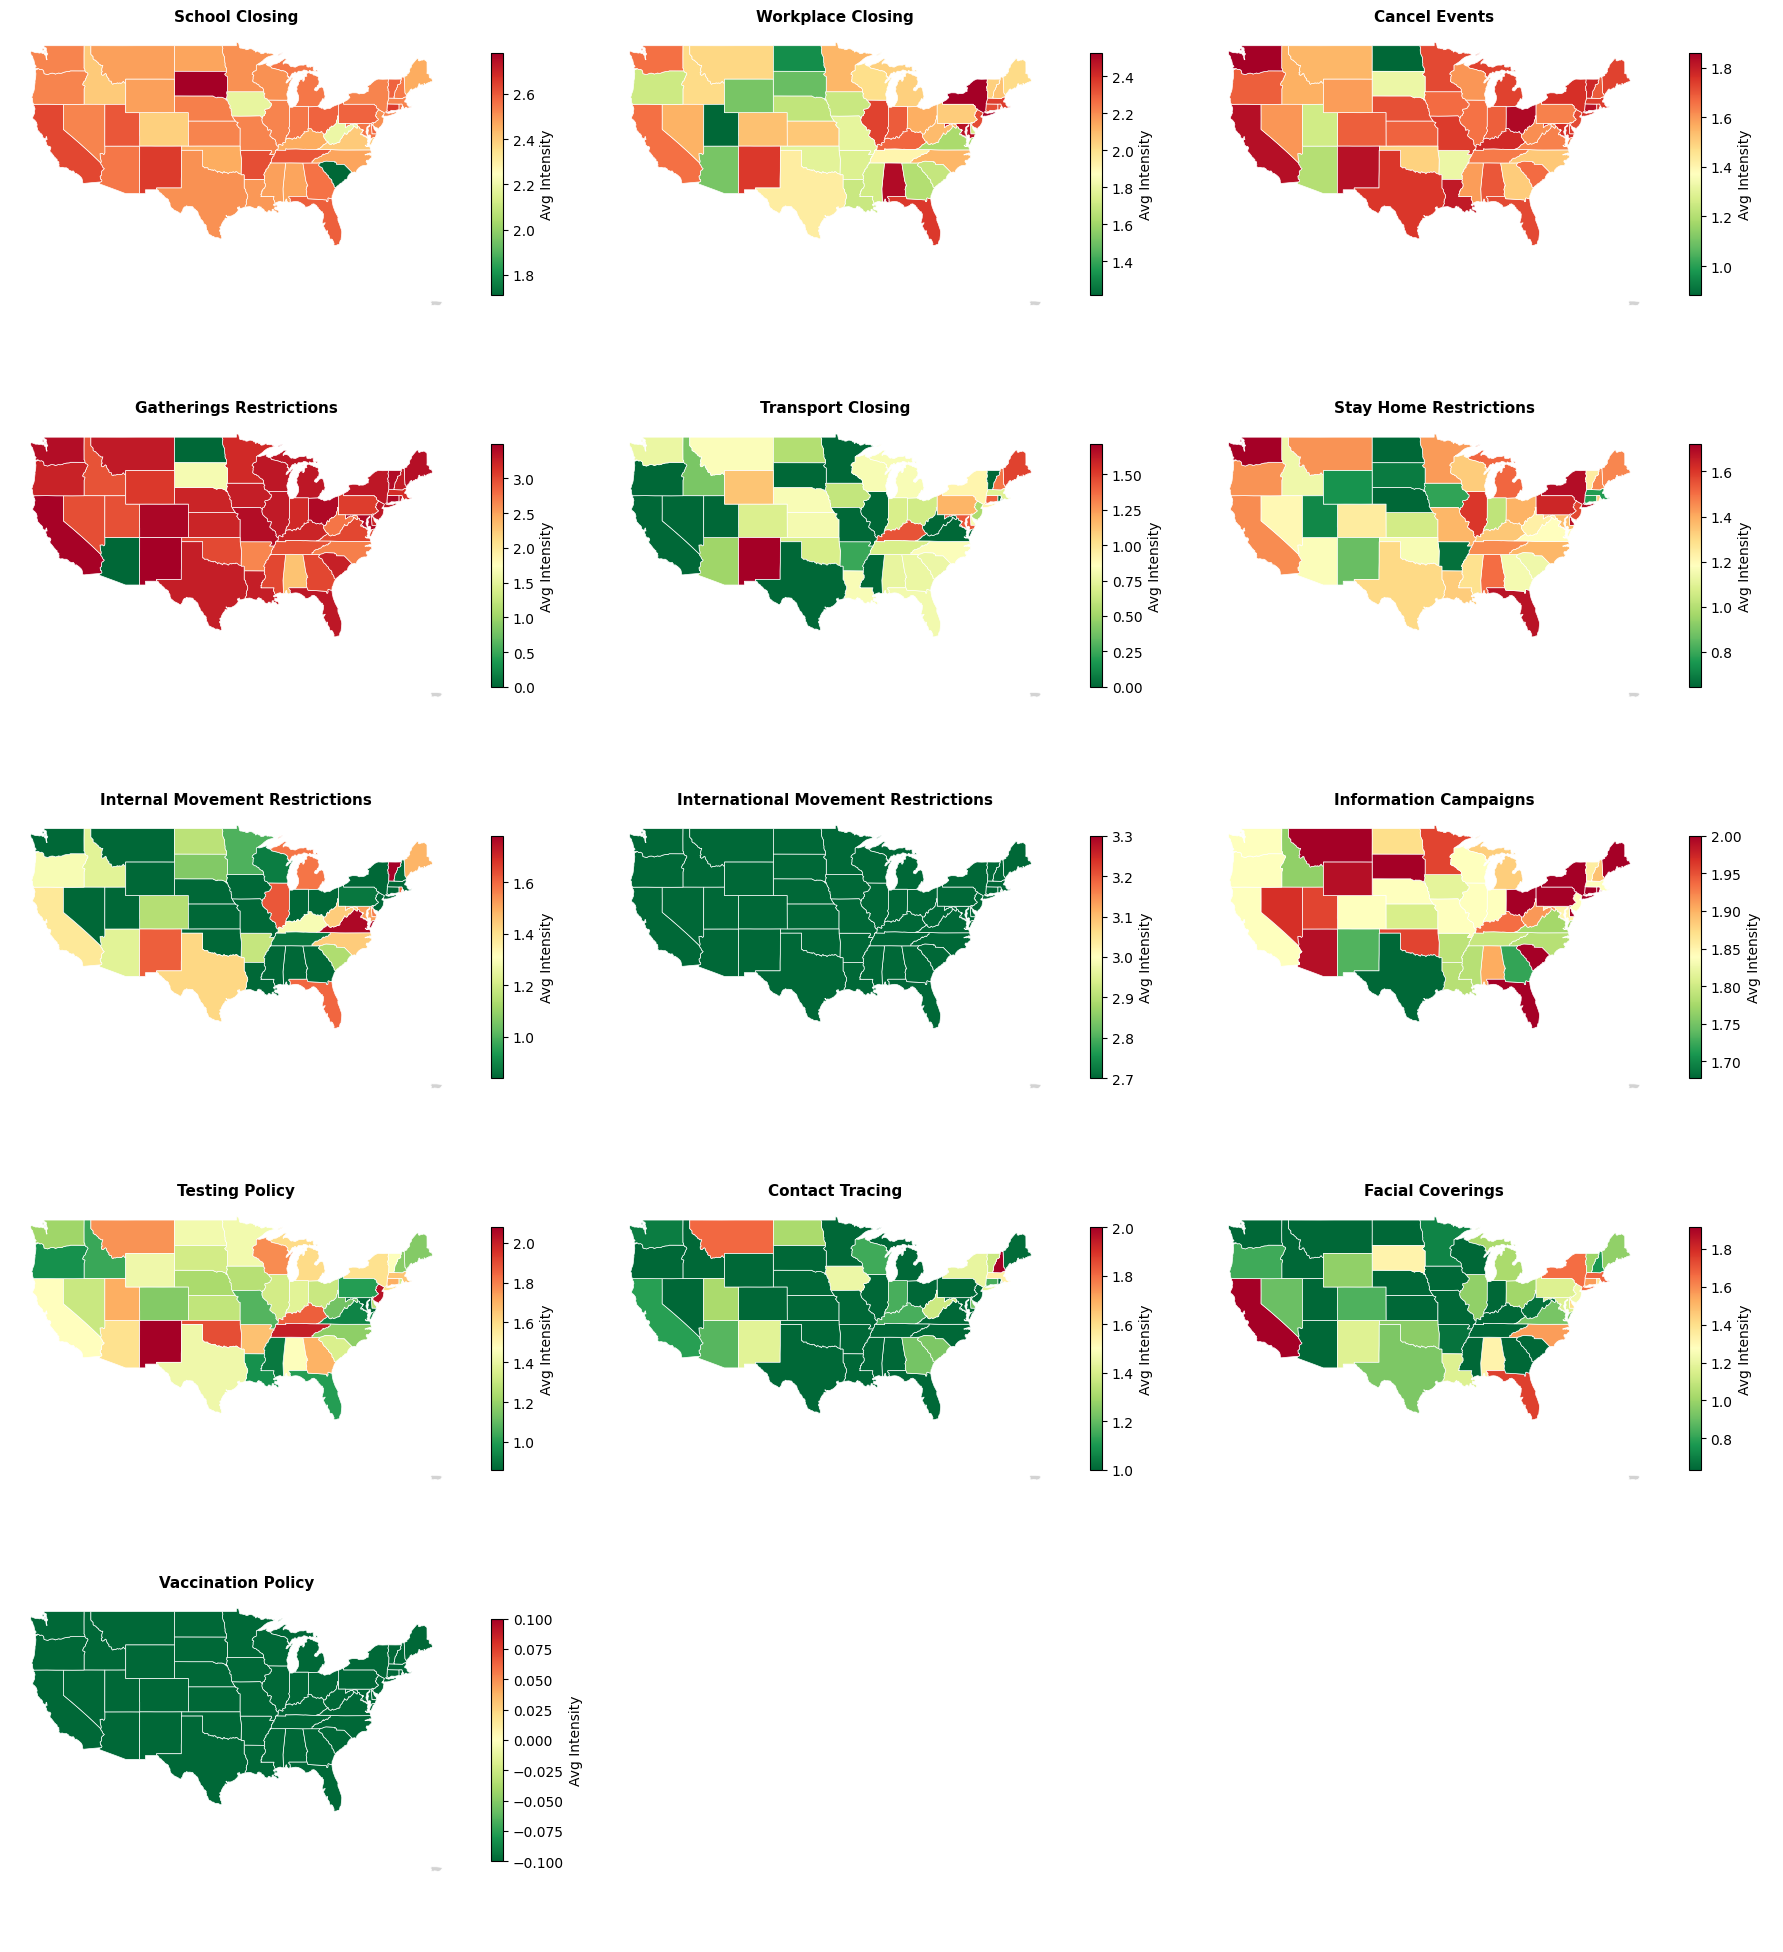

In [58]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Load US states shapefile — geopandas has this built in
url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
gdf = gpd.read_file(url)

# Merge with your data — check what the state name column is called in gdf
print(gdf.columns)  # likely 'name'
gdf = gdf.merge(analysis_dta, left_on='name', right_on='State', how='left')

# Drop Alaska and Hawaii for cleaner continental US map (optional)
gdf = gdf[~gdf['name'].isin(['Alaska', 'Hawaii'])]

# Plot one map per policy variable in a grid
n_cols = 3
n_rows = -(-len(policy_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(policy_cols):
    ax = axes[i]
    gdf.plot(
        column=col,
        ax=ax,
        cmap='RdYlGn_r',     # red = high restriction, green = low
        legend=True,
        legend_kwds={
            'shrink': 0.6,
            'label': 'Avg Intensity'
        },
        missing_kwds={'color': 'lightgrey', 'label': 'No data'},
        edgecolor='white',
        linewidth=0.5
    )
    ax.set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.axis('off')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [59]:
feature_cols=['State',
    'school_closing',
    'workplace_closing',
    'cancel_events',
    'gatherings_restrictions',
    'transport_closing',
    'stay_home_restrictions',
    'internal_movement_restrictions',
    'testing_policy',
    'contact_tracing',
    'facial_coverings']


In [79]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, RocCurveDisplay)
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# STEP 1: PREP
# =============================================================================

feature_cols = [
    'school_closing', 'workplace_closing', 'cancel_events',
    'gatherings_restrictions', 'transport_closing', 'stay_home_restrictions',
    'internal_movement_restrictions', 'testing_policy', 'contact_tracing',
    'facial_coverings'
]
# Note: dropping 'State' from features — it's an identifier not a predictor

X = analysis_dta[feature_cols]
y = analysis_dta['Party']  # 'Republican' / 'Democratic'

# =============================================================================
# STEP 2: TRAIN/TEST SPLIT
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y   # ensures both splits have balanced R/D representation
)

print(f"Training set: {len(X_train)} states")
print(f"Test set:     {len(X_test)} states")
print(f"\nTraining Party distribution:\n{y_train.value_counts()}")
print(f"\nTest Party distribution:\n{y_test.value_counts()}")

# =============================================================================
# STEP 3: SCALE AND FIT
# =============================================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test_scaled  = scaler.transform(X_test)         # apply same scale to test

model = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
# C=0.1 = regularization, important with small N
model.fit(X_train_scaled, y_train)


Training set: 35 states
Test set:     15 states

Training Party distribution:
Party
Republican    18
Democratic    17
Name: count, dtype: int64

Test Party distribution:
Party
Republican    8
Democratic    7
Name: count, dtype: int64


,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [80]:
# =============================================================================
# STEP 4: EVALUATE
# =============================================================================

y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"AUC: {roc_auc_score(y_test, y_pred_prob):.3f}")



--- Classification Report ---
              precision    recall  f1-score   support

  Democratic       0.56      0.71      0.62         7
  Republican       0.67      0.50      0.57         8

    accuracy                           0.60        15
   macro avg       0.61      0.61      0.60        15
weighted avg       0.61      0.60      0.60        15

AUC: 0.679


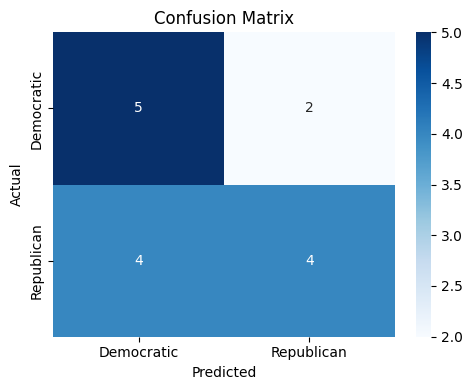

In [81]:
# =============================================================================
# STEP 5: CONFUSION MATRIX
# =============================================================================

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

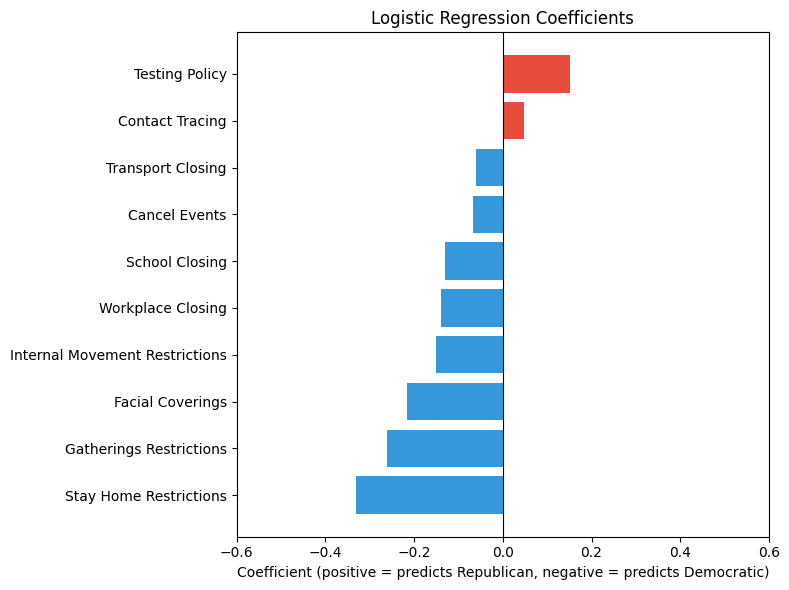


Coefficients (sorted by abs value):
                          feature  coefficient
5          stay_home_restrictions    -0.331064
3         gatherings_restrictions    -0.261617
9                facial_coverings    -0.216863
7                  testing_policy     0.151735
6  internal_movement_restrictions    -0.149966
1               workplace_closing    -0.138777
0                  school_closing    -0.130748
2                   cancel_events    -0.068251
4               transport_closing    -0.061363
8                 contact_tracing     0.047601


In [82]:
# =============================================================================
# STEP 6: COEFFICIENTS — which policies matter most
# =============================================================================

coef_df = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': model.coef_[0]
}).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'].str.replace('_', ' ').str.title(),
        coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-0.6, 0.6)
ax.set_xlabel(f'Coefficient (positive = predicts {model.classes_[1]}, negative = predicts {model.classes_[0]})')
ax.set_title('Logistic Regression Coefficients')
plt.tight_layout()
plt.show()

print("\nCoefficients (sorted by abs value):")
print(coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index))


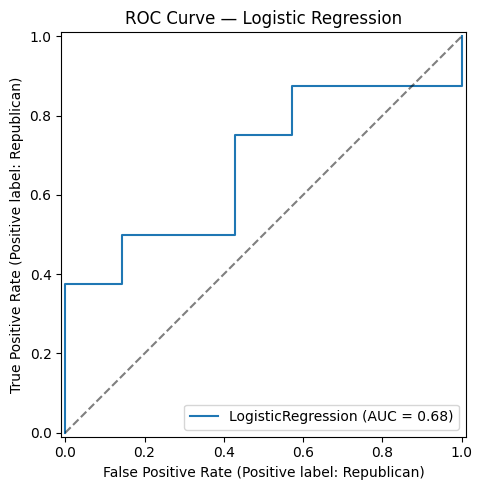

In [83]:

# =============================================================================
# STEP 7: ROC CURVE
# =============================================================================

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_title('ROC Curve — Logistic Regression')
plt.tight_layout()
plt.show()

In [84]:


# =============================================================================
# STEP 8: SEE WHICH STATES WERE MISCLASSIFIED
# =============================================================================

test_states = analysis_dta.loc[X_test.index, 'State'].values

results_df = pd.DataFrame({
    'State':          test_states,
    'Actual':         y_test.values,
    'Predicted':      y_pred,
    'Prob_class1':    y_pred_prob.round(3),
    'Correct':        y_test.values == y_pred
}).sort_values('Prob_class1', ascending=False)

print("\nTest set predictions:")
print(results_df.to_string(index=False))
print(f"\nMisclassified states:")
print(results_df[~results_df['Correct']][['State', 'Actual', 'Predicted', 'Prob_class1']])


Test set predictions:
        State     Actual  Predicted  Prob_class1  Correct
 North Dakota Republican Republican        0.946     True
 South Dakota Republican Republican        0.776     True
      Wyoming Republican Republican        0.704     True
       Kansas Democratic Republican        0.577    False
  Mississippi Republican Republican        0.576     True
    Wisconsin Democratic Republican        0.575    False
     Kentucky Democratic Democratic        0.489     True
New Hampshire Republican Democratic        0.458    False
        Texas Republican Democratic        0.453    False
   New Jersey Democratic Democratic        0.422     True
         Ohio Republican Democratic        0.395    False
     Michigan Democratic Democratic        0.342     True
 Pennsylvania Democratic Democratic        0.321     True
 Rhode Island Democratic Democratic        0.310     True
     Maryland Republican Democratic        0.227    False

Misclassified states:
            State      Act

In [66]:
state_party_affiliation_2020_2021=pd.read_csv("pol_lean.csv")
leaning=analysis_dta.merge(state_party_affiliation_2020_2021, how='left', on="State")


In [67]:
leaning.head()

,State,Party,school_closing,workplace_closing,cancel_events,gatherings_restrictions,transport_closing,stay_home_restrictions,internal_movement_restrictions,international_movement_restrictions,information_campaigns,testing_policy,contact_tracing,facial_coverings,vaccination_policy,Unnamed: 0,Partisan Lean,Party of Partisan Lean
0,Alabama,Republican,2.473118,2.494624,1.698925,2.290323,0.752688,1.505376,0.838710,3.0,1.903226,1.462366,1.000000,1.322581,0.0,43,-29.6,Republican
1,Alaska,Republican,2.548387,1.795699,1.430108,2.838710,1.440860,1.129032,1.354839,3.0,2.000000,1.580645,1.881720,0.634409,0.0,31,-14.6,Republican
2,Arizona,Republican,2.548387,1.516129,1.204301,0.000000,0.494624,1.172043,1.236559,3.0,1.989247,1.580645,1.182796,0.634409,0.0,26,-7.6,Republican
3,Arkansas,Republican,2.622222,1.755556,1.322222,2.655556,0.244444,0.666667,1.177778,3.0,1.788889,1.666667,1.000000,0.666667,0.0,44,-31.8,Republican
4,California,Democratic,2.634409,2.258065,1.827957,3.462366,0.000000,1.451613,1.376344,3.0,1.838710,1.473118,1.118280,1.913978,0.0,5,25.5,Democrat


In [68]:
from sklearn.linear_model import LinearRegression

In [69]:
# =============================================================================
# STEP 1: PREP
# =============================================================================

feature_cols = [
    'school_closing', 'workplace_closing', 'cancel_events',
    'gatherings_restrictions', 'transport_closing', 'stay_home_restrictions',
    'internal_movement_restrictions', 'testing_policy', 'contact_tracing',
    'facial_coverings'
]
# Note: dropping 'State' from features — it's an identifier not a predictor

X = leaning[feature_cols]
y = leaning['Partisan Lean']  # 'Republican' / 'Democratic'

# =============================================================================
# STEP 2: TRAIN/TEST SPLIT
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42   # ensures both splits have balanced R/D representation
)

print(f"Training set: {len(X_train)} states")
print(f"Test set:     {len(X_test)} states")
print(f"\nTraining Party distribution:\n{y_train.value_counts()}")
print(f"\nTest Party distribution:\n{y_test.value_counts()}")

# =============================================================================
# STEP 3: SCALE AND FIT
# =============================================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test_scaled  = scaler.transform(X_test)         # apply same scale to test

model = LinearRegression()
model.fit(X_train_scaled, y_train)


Training set: 40 states
Test set:     10 states

Training Party distribution:
Partisan Lean
-7.6     2
-37.2    2
 25.5    1
-2.9     1
-31.8    1
 13.4    1
 12.1    1
-29.4    1
-35.5    1
 12.4    1
-7.4     1
-27.1    1
-21.2    1
-20.7    1
-12.4    1
 20.0    1
 27.5    1
-29.6    1
-2.5     1
 6.4     1
 12.0    1
-37.0    1
 10.6    1
-14.6    1
-1.6     1
-26.3    1
-20.3    1
-32.2    1
 31.6    1
 1.9     1
 4.0     1
-49.7    1
 32.6    1
 13.7    1
-12.0    1
-9.7     1
 0.3     1
 24.0    1
Name: count, dtype: int64

Test Party distribution:
Partisan Lean
-20.0    2
-18.6    1
 7.0     1
 4.6     1
-20.5    1
-4.1     1
-24.8    1
-4.8     1
 25.9    1
Name: count, dtype: int64


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [70]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluate
print(f"\nR²:   {r2_score(y_test, y_pred):.3f}")
# R² = proportion of variance in partisan lean explained by policies
# 1.0 = perfect, 0.0 = no better than predicting the mean

print(f"MAE:  {mean_absolute_error(y_test, y_pred):.3f}")
# Average error in partisan lean points

print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")


R²:   0.003
MAE:  12.933
RMSE: 15.453



Coefficients:
                          feature  coefficient
4               transport_closing    -5.158709
7                  testing_policy    -0.231311
2                   cancel_events     0.193467
6  internal_movement_restrictions     2.569687
0                  school_closing     2.655183
3         gatherings_restrictions     3.546837
1               workplace_closing     4.410662
5          stay_home_restrictions     4.792513
9                facial_coverings     6.385362
8                 contact_tracing     7.921648


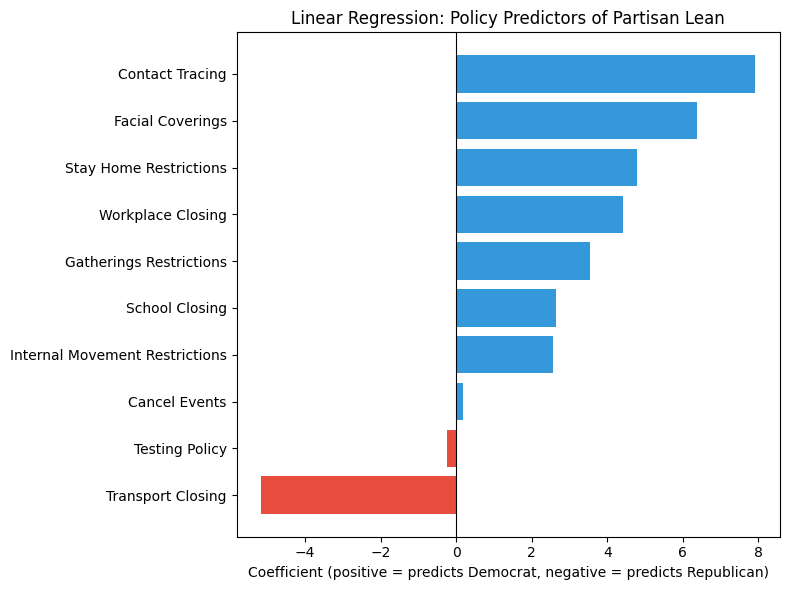

In [71]:

# Coefficients
coef_df = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': model.coef_
}).sort_values('coefficient')

print("\nCoefficients:")
print(coef_df)
# Positive coefficient = higher policy intensity → more Democratic
# Negative coefficient = higher policy intensity → more Republican

# Plot coefficients
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#3498db' if c > 0 else '#e74c3c' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'].str.replace('_', ' ').str.title(),
        coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (positive = predicts Democrat, negative = predicts Republican)')
ax.set_title('Linear Regression: Policy Predictors of Partisan Lean')
plt.tight_layout()
plt.show()


Test set predictions:
         State  Actual  Predicted
      Maryland    25.9      -2.58
    New Mexico     7.0       2.15
      Virginia     4.6      -9.91
     Wisconsin    -4.1     -15.21
North Carolina    -4.8      -0.69
South Carolina   -18.6     -36.77
       Indiana   -20.0     -13.55
       Montana   -20.0       6.60
     Louisiana   -20.5     -15.21
      Nebraska   -24.8     -34.55


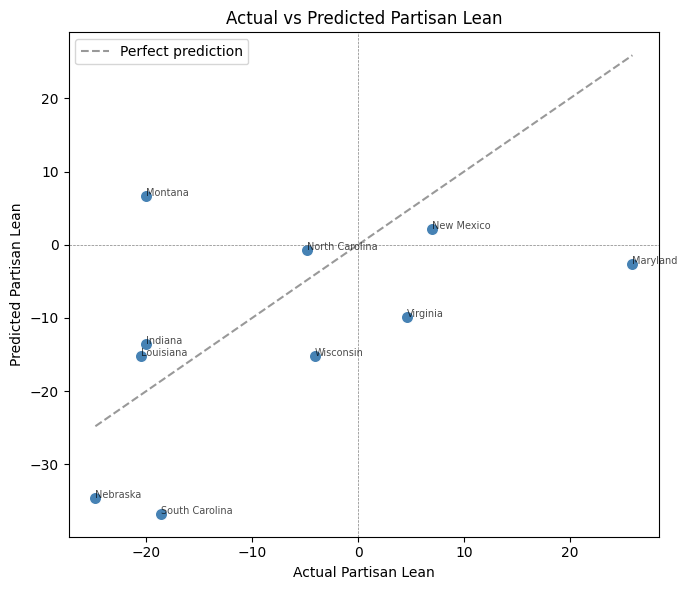

In [72]:
# Actual vs predicted plot
test_states = analysis_dta.loc[X_test.index, 'State'].values
results_df = pd.DataFrame({
    'State':     test_states,
    'Actual':    y_test.values,
    'Predicted': y_pred.round(2)
}).sort_values('Actual', ascending=False)

print("\nTest set predictions:")
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, color='steelblue', edgecolor='white', s=80)
for i, row in results_df.iterrows():
    ax.annotate(row['State'], (row['Actual'], row['Predicted']),
                fontsize=7, alpha=0.7)
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()], 'k--', alpha=0.4, label='Perfect prediction')
ax.set_xlabel('Actual Partisan Lean')
ax.set_ylabel('Predicted Partisan Lean')
ax.set_title('Actual vs Predicted Partisan Lean')
ax.legend()
plt.tight_layout()
plt.show()

In [85]:

# =============================================================================
# STEP 1: PREP
# =============================================================================

feature_cols = [
    'school_closing', 'workplace_closing', 'cancel_events',
    'gatherings_restrictions', 'transport_closing', 'stay_home_restrictions',
    'internal_movement_restrictions', 'testing_policy', 'contact_tracing',
    'facial_coverings'
]
# Note: dropping 'State' from features — it's an identifier not a predictor

X = leaning[feature_cols]
y = leaning['Party of Partisan Lean']  # 'Republican' / 'Democratic'

# =============================================================================
# STEP 2: TRAIN/TEST SPLIT
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y   # ensures both splits have balanced R/D representation
)

print(f"Training set: {len(X_train)} states")
print(f"Test set:     {len(X_test)} states")
print(f"\nTraining Party distribution:\n{y_train.value_counts()}")
print(f"\nTest Party distribution:\n{y_test.value_counts()}")

# =============================================================================
# STEP 3: SCALE AND FIT
# =============================================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test_scaled  = scaler.transform(X_test)         # apply same scale to test

model = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
# C=0.1 = regularization, important with small N
model.fit(X_train_scaled, y_train)

Training set: 35 states
Test set:     15 states

Training Party distribution:
Party of Partisan Lean
Republican    22
Democrat      13
Name: count, dtype: int64

Test Party distribution:
Party of Partisan Lean
Republican    9
Democrat      6
Name: count, dtype: int64


,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [86]:
# =============================================================================
# STEP 4: EVALUATE
# =============================================================================

y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"AUC: {roc_auc_score(y_test, y_pred_prob):.3f}")



--- Classification Report ---
              precision    recall  f1-score   support

    Democrat       0.50      0.17      0.25         6
  Republican       0.62      0.89      0.73         9

    accuracy                           0.60        15
   macro avg       0.56      0.53      0.49        15
weighted avg       0.57      0.60      0.54        15

AUC: 0.630


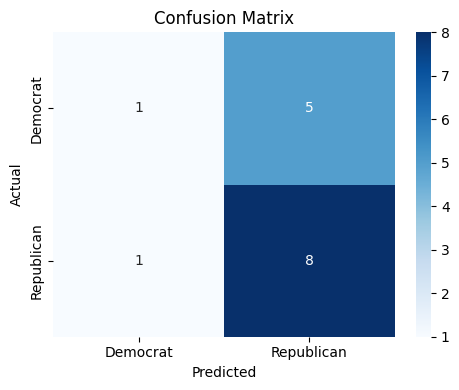

In [87]:
# =============================================================================
# STEP 5: CONFUSION MATRIX
# =============================================================================

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

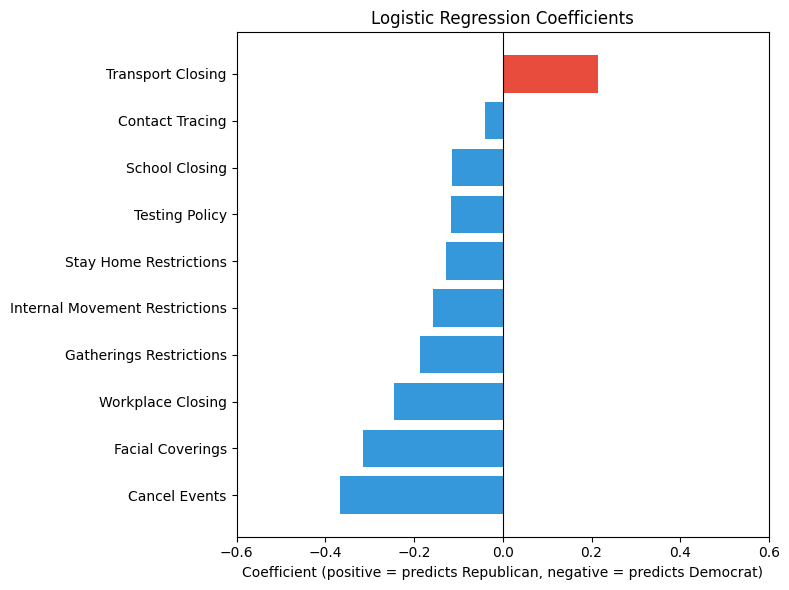


Coefficients (sorted by abs value):
                          feature  coefficient
2                   cancel_events    -0.367937
9                facial_coverings    -0.316120
1               workplace_closing    -0.244127
4               transport_closing     0.215438
3         gatherings_restrictions    -0.187091
6  internal_movement_restrictions    -0.157977
5          stay_home_restrictions    -0.127909
7                  testing_policy    -0.116785
0                  school_closing    -0.113895
8                 contact_tracing    -0.040278


In [88]:
# =============================================================================
# STEP 6: COEFFICIENTS — which policies matter most
# =============================================================================

coef_df = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': model.coef_[0]
}).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'].str.replace('_', ' ').str.title(),
        coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-0.6, 0.6)
ax.set_xlabel(f'Coefficient (positive = predicts {model.classes_[1]}, negative = predicts {model.classes_[0]})')
ax.set_title('Logistic Regression Coefficients')
plt.tight_layout()
plt.show()

print("\nCoefficients (sorted by abs value):")
print(coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index))


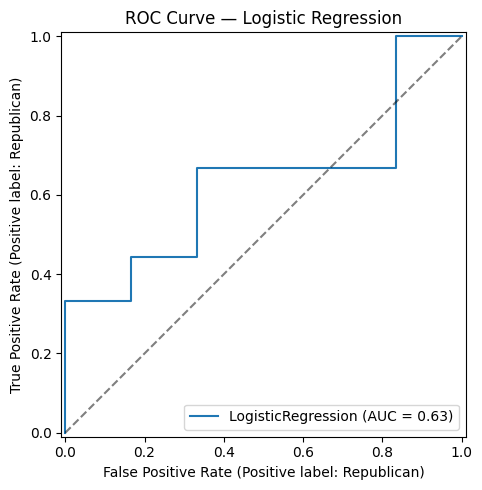

In [89]:

# =============================================================================
# STEP 7: ROC CURVE
# =============================================================================

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_title('ROC Curve — Logistic Regression')
plt.tight_layout()
plt.show()

In [90]:


# =============================================================================
# STEP 8: SEE WHICH STATES WERE MISCLASSIFIED
# =============================================================================

test_states = analysis_dta.loc[X_test.index, 'State'].values

results_df = pd.DataFrame({
    'State':          test_states,
    'Actual':         y_test.values,
    'Predicted':      y_pred,
    'Prob_class1':    y_pred_prob.round(3),
    'Correct':        y_test.values == y_pred
}).sort_values('Prob_class1', ascending=False)

print("\nTest set predictions:")
print(results_df.to_string(index=False))
print(f"\nMisclassified states:")
print(results_df[~results_df['Correct']][['State', 'Actual', 'Predicted', 'Prob_class1']])


Test set predictions:
        State     Actual  Predicted  Prob_class1  Correct
         Utah Republican Republican        0.891     True
       Alaska Republican Republican        0.832     True
     Nebraska Republican Republican        0.824     True
       Hawaii   Democrat Republican        0.815    False
     Oklahoma Republican Republican        0.762     True
New Hampshire   Democrat Republican        0.707    False
    Louisiana Republican Republican        0.685     True
    Tennessee Republican Republican        0.683     True
        Maine   Democrat Republican        0.665    False
       Oregon   Democrat Republican        0.638    False
     Maryland   Democrat Republican        0.543    False
      Alabama Republican Republican        0.537     True
         Ohio Republican Republican        0.537     True
        Texas Republican   Democrat        0.494    False
   New Mexico   Democrat   Democrat        0.432     True

Misclassified states:
            State      Act